# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [ ]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [ ]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phan Dương Định"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600277"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%);
                color: white; padding: 15px; border-radius: 10px;
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} |
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [ ]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://algebra-donors-split-metres.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [ ]:
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 6 nodes

🖥️  node-00:
   GPU 0 [T4] 🔴 Util: 63.5% | Mem: 11.9/16.0GB | Power: 66W | Temp: 68°C
   GPU 1 [T4] 🔴 Util: 83.4% | Mem: 11.3/16.0GB | Power: 46W | Temp: 56°C

🖥️  node-01:
   GPU 0 [A100] 🔴 Util: 61.0% | Mem: 49.5/80.0GB | Power: 211W | Temp: 80°C
   GPU 1 [A100] 🔴 Util: 88.7% | Mem: 58.1/80.0GB | Power: 259W | Temp: 65°C

🖥️  node-02:
   GPU 0 [V100] 🔴 Util: 91.3% | Mem: 16.2/32.0GB | Power: 189W | Temp: 64°C
   GPU 1 [V100] 🔴 Util: 84.1% | Mem: 24.1/32.0GB | Power: 230W | Temp: 75°C

🖥️  node-03:
   GPU 0 [T4] 🔴 Util: 80.5% | Mem: 12.7/16.0GB | Power: 62W | Temp: 68°C
   GPU 1 [T4] 🔴 Util: 93.6% | Mem: 9.0/16.0GB | Power: 49W | Temp: 55°C

🖥️  node-04:
   GPU 0 [T4] 🟢 Util: 2.5% | Mem: 1.1/16.0GB | Power: 24W | Temp: 40°C
   GPU 1 [T4] 🟢 Util: 6.6% | Mem: 1.7/16.0GB | Power: 31W | Temp: 43°C

🖥️  node-05:
   GPU 0 [T4] 🟢 Util: 0.0% | Mem: 0.5/16.0GB | Power: 20W | Temp: 30°C
   GPU 1 [T4] 🟢 Util: 0.0% | Mem: 0.5/16.0GB | Power: 20W | Temp: 30°C


In [ ]:
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          12
Busy GPUs:           8
Idle GPUs:           4
Avg Utilization:     54.6%
Memory Used:         196.6 GB
Memory Capacity:     352.0 GB
Total Power Draw:    1207 W
Node Count:          6


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [ ]:
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-04', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-04', 'gpu_id': 1}]
   inference-api-003: running → [{'node_id': 'node-05', 'gpu_id': 0}]
   train-llm-004: running → [{'node_id': 'node-05', 'gpu_id': 1}]

📊 Updated metrics:
   Busy GPUs: 12/12 | Utilization: 79.0%


In [ ]:
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $2.6465
   Total Savings:  $2.7078
   Budget Used:    2.6%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [ ]:
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2671     23.7    % low
A100       $3.67       $2.5057     31.7    % medium
V100       $2.48       $1.6022     35.4    % low


In [ ]:
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [ ]:
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 0
   Still active: 7

💰 Spot Savings Report:
   Spot cost:        $0.1106
   On-demand equiv:  $0.3686
   Total saved:      $0.2580 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [ ]:
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 70.0
   scale_down_threshold: 25.0
   cooldown_seconds: 30
   max_nodes: 10
   min_nodes: 2
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [ ]:
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ⬆️ Action: SCALE_UP
   Reason: Utilization 79.0% > threshold 70.0%
   Current utilization: 79.0%
   Nodes: 6 → 7

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 67.7% | Nodes: 7→7
   Cycle 2: no_action    | Util: 67.7% | Nodes: 7→7
   Cycle 3: no_action    | Util: 67.7% | Nodes: 7→7
   Cycle 4: no_action    | Util: 67.7% | Nodes: 7→7
   Cycle 5: no_action    | Util: 67.7% | Nodes: 7→7


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [ ]:
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.043889 | Idle=$0.001944 | Waste=4.4%
   Snapshot 2: Total=$0.043889 | Idle=$0.001944 | Waste=4.4%
   Snapshot 3: Total=$0.043889 | Idle=$0.001944 | Waste=4.4%
   Snapshot 4: Total=$0.043889 | Idle=$0.001944 | Waste=4.4%
   Snapshot 5: Total=$0.043889 | Idle=$0.001944 | Waste=4.4%


In [ ]:
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          4.6%
   Total Idle Cost:        $0.019440
   Total Cost:             $0.421389
   Potential Monthly Save:  $503.88
   Severity:               LOW


In [ ]:
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [ ]:
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 14 GPUs across 7 nodes
   Utilization: 67.7% | Busy: 12 | Idle: 2

💰 BILLING: $2.6465 / $100.00 budget
   Alert: OK | Savings: $2.7078

🎯 SPOT: Saved $0.2852 (70.0%)

🗑️  WASTE: 4.6% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

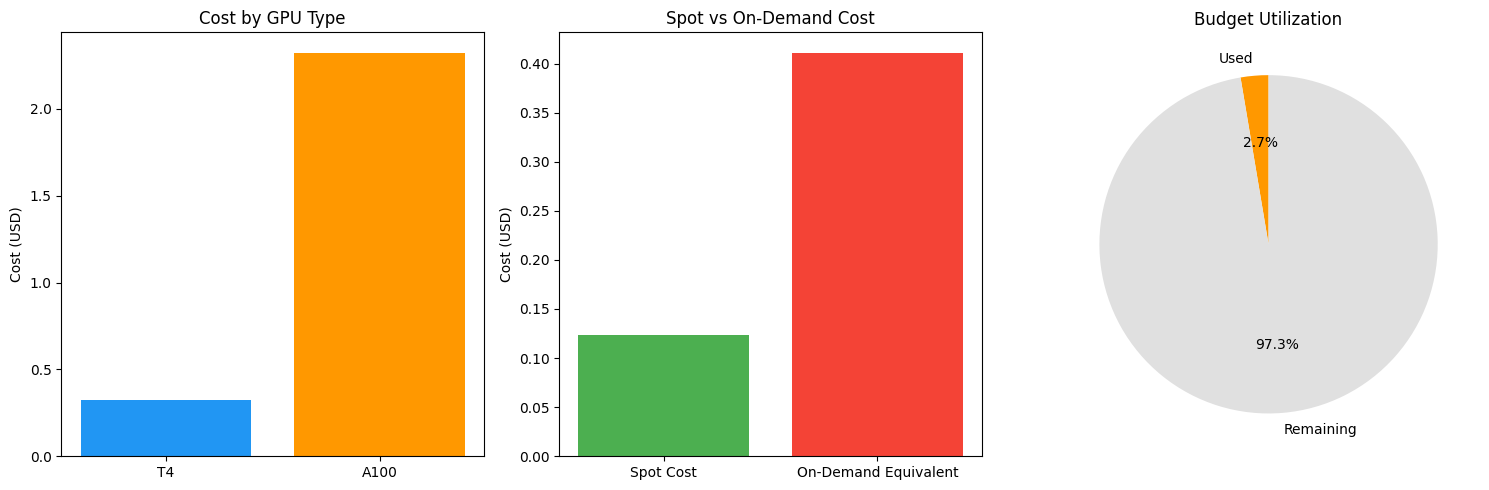

📊 Chart saved as finops_cost_breakdown.png


In [ ]:
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


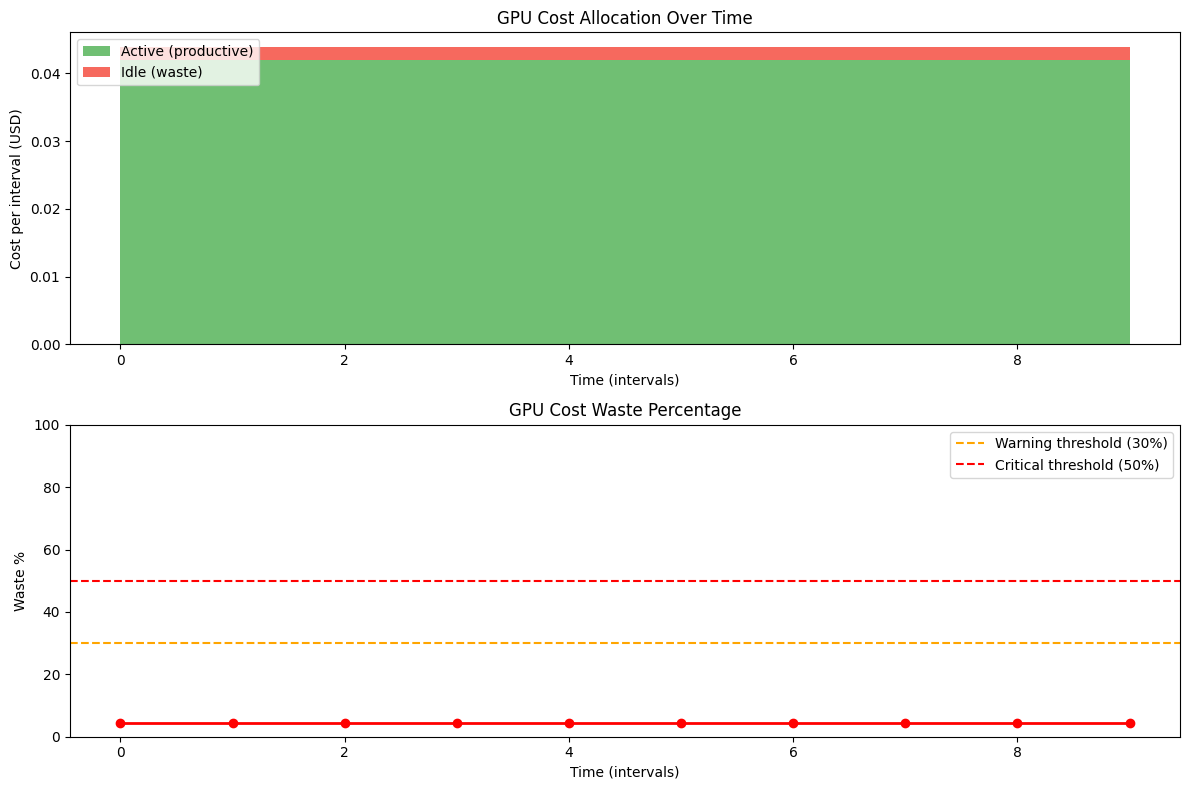

In [ ]:
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [ ]:
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 14 | Util: 67.7% | Idle: 2

2️⃣  Submitting heavy workloads...
   After load: Util: 76.8% | Busy: 14/14

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 76.8% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.045833
   Waste: 4.2%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.2766 (70.0%)

7️⃣  Final billing:
   Total spend: $2.8156
   Total saved: $2.8302
   Budget: 2.8% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [ ]:
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [ ]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 13.9W
   Temp: 49C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 13.926
   temp_c: 49.0

   Method: pynvml

Ready for training.


In [ ]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:04<00:00, 39.1MB/s]


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [ ]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 2.1955 | Acc: 25.0% | Time: 41.4s | Samples: 40
   Epoch 2/3 | Loss: 1.5510 | Acc: 42.7% | Time: 43.5s | Samples: 40
   Epoch 3/3 | Loss: 1.3131 | Acc: 52.3% | Time: 44.6s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      129.5s
   Peak memory:     0.82 GB
   Avg GPU util:    94.5%
   Avg power:       67.4W
   Avg temperature: 72.8C
   Max GPU util:    99.0%
   Estimated cost:  $0.012594


In [ ]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_1236/927799492.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_1236/927799492.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.9639 | Acc: 29.5% | Time: 23.5s | Samples: 40
   Epoch 2/3 | Loss: 1.4468 | Acc: 46.7% | Time: 23.3s | Samples: 40
   Epoch 3/3 | Loss: 1.1390 | Acc: 58.9% | Time: 23.3s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      70.1s
   Peak memory:     0.60 GB
   Avg GPU util:    72.0%
   Avg power:       64.5W
   Avg temperature: 76.7C
   Max GPU util:    88.0%
   Estimated cost:  $0.006819


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                129.5           70.1            1.85x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.012594       $0.006819       $0.005776 saved
Cost Saving %             ---             ---             45.9%
Avg GPU Util %            94.5            72.0           
Avg Power (W)             67.4            64.5           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$4.55 -> SAVE $3.85
   1 week training: FP32=$58.80 vs AMP=$31.83 -> SAVE $26.97
   1 month training: FP32=$252.00 vs AMP=$136.44 -> SAVE $115.56


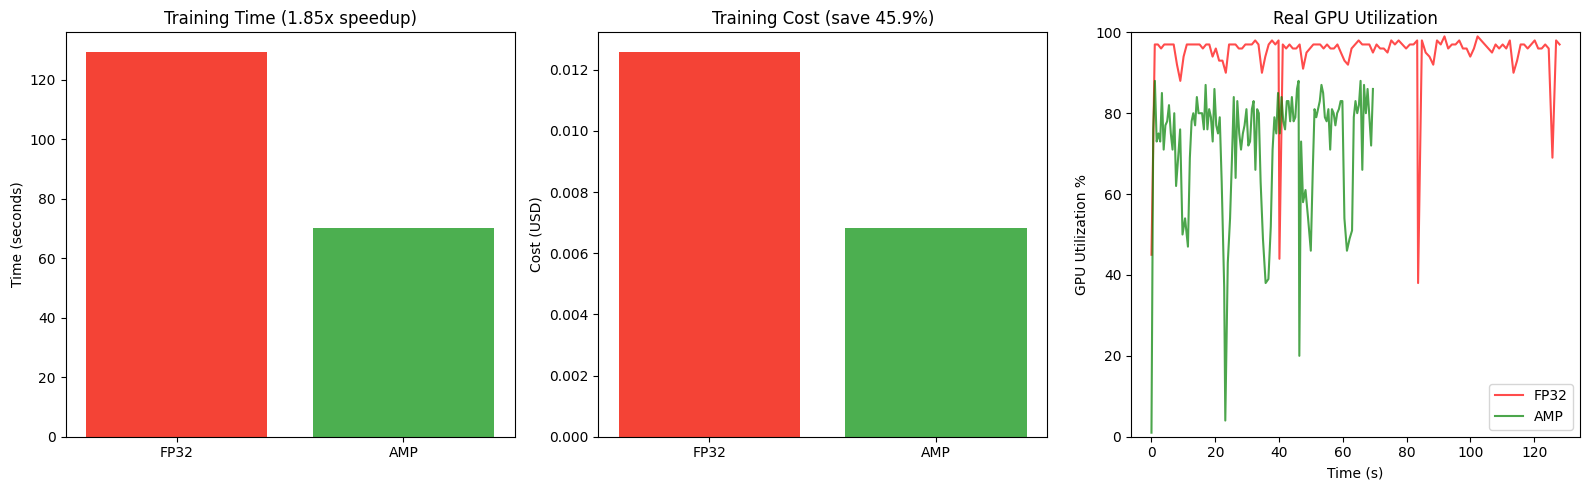

In [ ]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.012600 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.002000 | Saved: $0.004800

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.014600
   Total Savings:   $0.004800
   Workloads:       2

   Cost snapshot taken: waste=4.2%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $2.8156
   Total Savings:        $2.8302
   Budget Utilization:   2.8%
   Alert:                OK


Real GPU Telemetry During Training


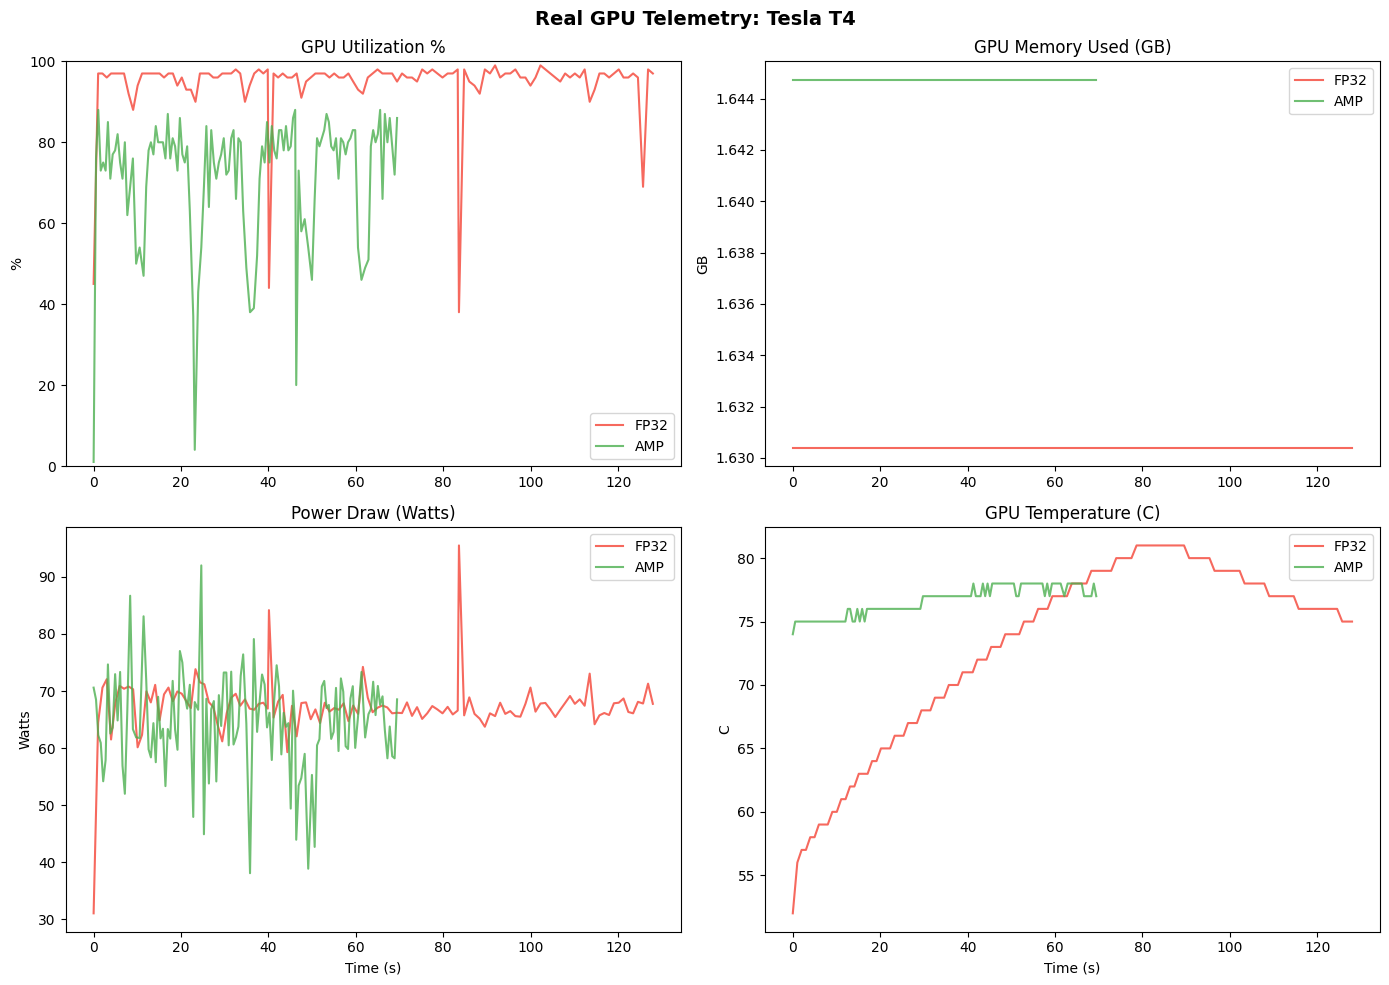

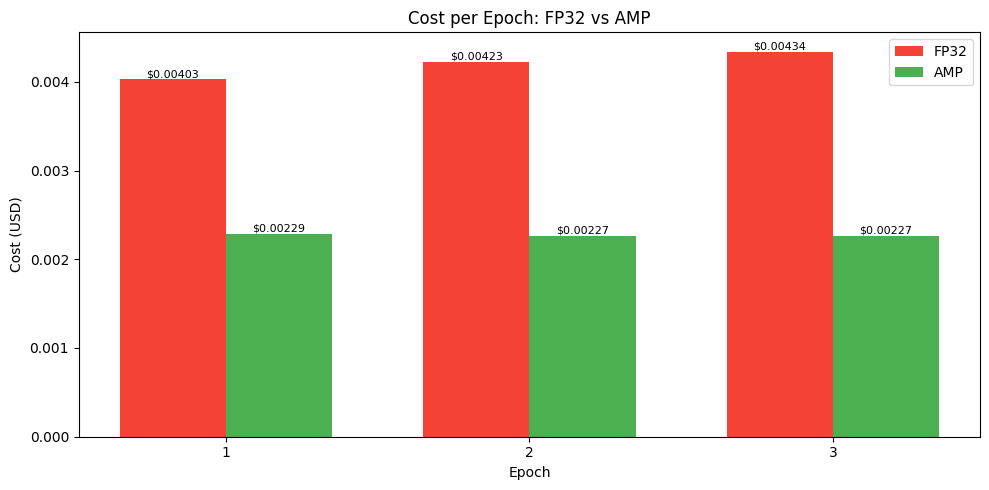


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [ ]:
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

EXERCISE 8.5.1: Multi-GPU Cost Analysis

GPU type: T4 ($0.35/h)


,gpu_count,speedup,efficiency,train_time_hours,total_cost_usd,cost_vs_1gpu_pct,throughput_per_dollar
0,1,1.00,1.00,2.0000,0.7000,0.00,1.4286
1,2,1.78,0.89,1.1236,0.7865,12.36,2.2631
2,4,3.32,0.83,0.6024,0.8434,20.48,3.9366
3,8,5.68,0.71,0.3521,0.9859,40.85,5.7611



✅ Best lowest absolute cost option:
{'gpu_count': 1, 'speedup': 1.0, 'efficiency': 1.0, 'train_time_hours': 2.0, 'total_cost_usd': 0.7, 'cost_vs_1gpu_pct': 0.0, 'throughput_per_dollar': 1.4286}

✅ Best performance-per-dollar option:
{'gpu_count': 8, 'speedup': 5.68, 'efficiency': 0.71, 'train_time_hours': 0.3521, 'total_cost_usd': 0.9859, 'cost_vs_1gpu_pct': 40.85, 'throughput_per_dollar': 5.7611}


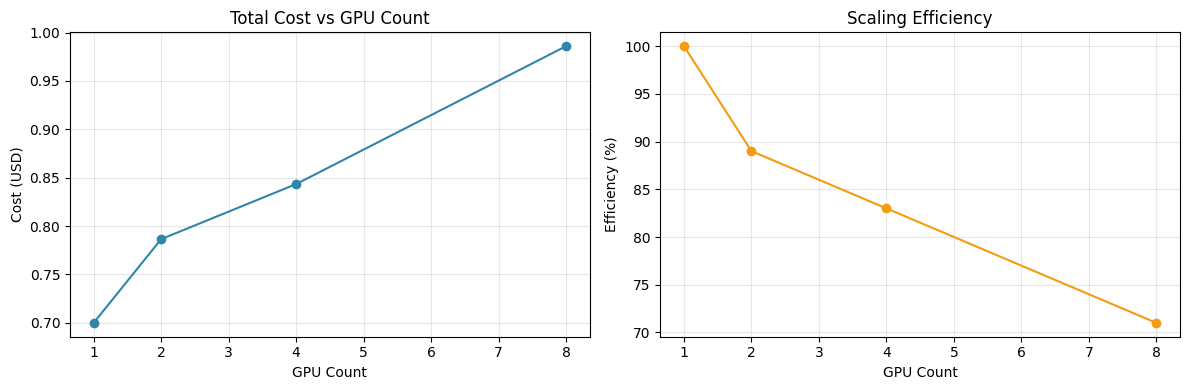

In [ ]:
# Cell 27: Multi-GPU Cost Analysis
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)


def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    pricing = globals().get("GPU_PRICING", {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81})
    price_per_hour = pricing.get(gpu_type, pricing.get("T4", 0.35))

    sorted_counts = sorted(gpu_counts)
    if scaling_factors is None:
        scaling_factors = {}
        for c in sorted_counts:
            if c == 1:
                scaling_factors[c] = 1.0
            else:
                efficiency = max(0.55, 0.92 - 0.06 * (c - 1) / 2)
                scaling_factors[c] = round(c * efficiency, 2)

    rows = []
    baseline_cost = None
    for c in sorted_counts:
        speedup = max(scaling_factors.get(c, 1.0), 1e-6)
        eff = speedup / c
        train_time = base_time_hours / speedup
        total_cost = train_time * price_per_hour * c
        if c == 1:
            baseline_cost = total_cost
        cost_change_pct = ((total_cost - baseline_cost) / baseline_cost * 100) if baseline_cost else 0

        rows.append({
            "gpu_count": c,
            "speedup": round(speedup, 3),
            "efficiency": round(eff, 3),
            "train_time_hours": round(train_time, 4),
            "total_cost_usd": round(total_cost, 4),
            "cost_vs_1gpu_pct": round(cost_change_pct, 2),
            "throughput_per_dollar": round(speedup / max(total_cost, 1e-9), 4),
        })

    best_cost = min(rows, key=lambda r: r["total_cost_usd"])
    best_perf_dollar = max(rows, key=lambda r: r["throughput_per_dollar"])

    return {
        "gpu_type": gpu_type,
        "price_per_hour": price_per_hour,
        "base_time_hours": base_time_hours,
        "scaling_factors": scaling_factors,
        "rows": rows,
        "best_cost_option": best_cost,
        "best_perf_dollar_option": best_perf_dollar,
    }


base_training_time = 2.0
test_gpu_counts = [1, 2, 4, 8]
gpu_type_for_analysis = globals().get("detected_type", "A100")

multi_gpu_analysis = analyze_multi_gpu_cost(base_training_time, gpu_type_for_analysis, test_gpu_counts)
analysis_df = pd.DataFrame(multi_gpu_analysis["rows"])

print("")
print(f"GPU type: {multi_gpu_analysis['gpu_type']} (${multi_gpu_analysis['price_per_hour']}/h)")
display(analysis_df)

print("")
print("✅ Best lowest absolute cost option:")
print(multi_gpu_analysis["best_cost_option"])
print("")
print("✅ Best performance-per-dollar option:")
print(multi_gpu_analysis["best_perf_dollar_option"])

fig, ax1 = plt.subplots(1, 2, figsize=(12, 4))
ax1[0].plot(analysis_df["gpu_count"], analysis_df["total_cost_usd"], marker="o", color="#2E86AB")
ax1[0].set_title("Total Cost vs GPU Count")
ax1[0].set_xlabel("GPU Count")
ax1[0].set_ylabel("Cost (USD)")
ax1[0].grid(alpha=0.3)

ax1[1].plot(analysis_df["gpu_count"], analysis_df["efficiency"] * 100, marker="o", color="#F39C12")
ax1[1].set_title("Scaling Efficiency")
ax1[1].set_xlabel("GPU Count")
ax1[1].set_ylabel("Efficiency (%)")
ax1[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("multi_gpu_scaling.png", dpi=150)
plt.show()


EXERCISE 8.5.2: Project Cost Forecasting


,name,gpu_type,gpu_count,duration_hours,phase_cost_usd,uncertainty_pct,phase_low_usd,phase_high_usd
0,Data Preparation,T4,1,40,14.0,0.15,9.88,18.12
1,Model Training,A100,4,120,1761.6,0.25,898.42,2624.78
2,Hyperparameter Tuning,A100,8,60,1761.6,0.30,725.78,2797.42
3,Model Evaluation,T4,2,20,14.0,0.10,11.26,16.74



Base total: 3551.2 USD
Contingency: 710.24 USD
Expected total: 4261.44 USD
Confidence interval: 2913.09 - 5609.79 USD


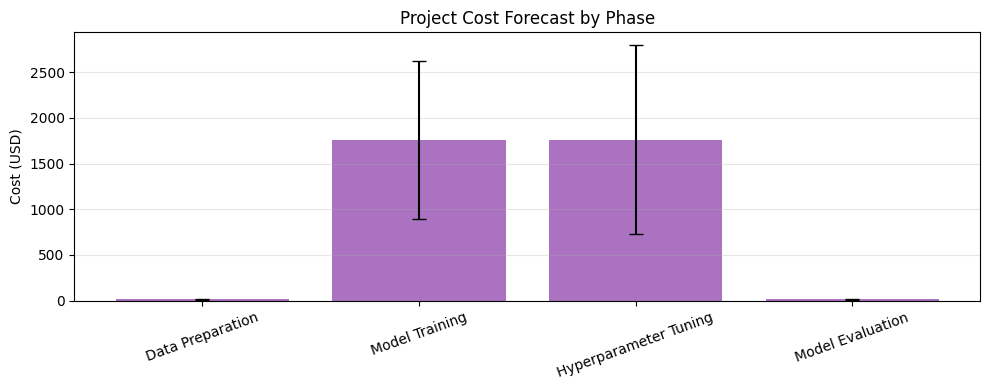

In [ ]:
# Cell 28: Project Cost Forecasting
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)


def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    pricing = globals().get("GPU_PRICING", {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81})
    z_lookup = {0.8: 1.28, 0.9: 1.645, 0.95: 1.96, 0.99: 2.576}
    z_score = z_lookup.get(round(confidence_level, 2), 1.96)

    phase_breakdown = []
    base_total = 0.0
    variance_sum = 0.0

    for p in phases:
        price = pricing.get(p["gpu_type"], pricing.get("T4", 0.35))
        phase_cost = p["duration_hours"] * p["gpu_count"] * price
        sigma = phase_cost * p.get("uncertainty_pct", 0.2)

        phase_breakdown.append({
            "name": p["name"],
            "gpu_type": p["gpu_type"],
            "gpu_count": p["gpu_count"],
            "duration_hours": p["duration_hours"],
            "phase_cost_usd": round(phase_cost, 2),
            "uncertainty_pct": p.get("uncertainty_pct", 0.2),
            "phase_low_usd": round(phase_cost - z_score * sigma, 2),
            "phase_high_usd": round(phase_cost + z_score * sigma, 2),
        })

        base_total += phase_cost
        variance_sum += sigma ** 2

    contingency_cost = base_total * (contingency_pct / 100)
    expected_total = base_total + contingency_cost
    total_sigma = variance_sum ** 0.5

    low_ci = expected_total - z_score * total_sigma
    high_ci = expected_total + z_score * total_sigma

    return {
        "confidence_level": confidence_level,
        "z_score": z_score,
        "phase_breakdown": phase_breakdown,
        "base_total_usd": round(base_total, 2),
        "contingency_pct": contingency_pct,
        "contingency_cost_usd": round(contingency_cost, 2),
        "expected_total_usd": round(expected_total, 2),
        "best_case_usd": round(max(0, low_ci), 2),
        "worst_case_usd": round(high_ci, 2),
    }


example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

project_forecast = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)
forecast_df = pd.DataFrame(project_forecast["phase_breakdown"])

display(forecast_df)
print("")
print("Base total:", project_forecast["base_total_usd"], "USD")
print("Contingency:", project_forecast["contingency_cost_usd"], "USD")
print("Expected total:", project_forecast["expected_total_usd"], "USD")
print("Confidence interval:", project_forecast["best_case_usd"], "-", project_forecast["worst_case_usd"], "USD")

fig, ax = plt.subplots(figsize=(10, 4))
names = forecast_df["name"].tolist()
phase_costs = forecast_df["phase_cost_usd"].tolist()
err_low = [c - l for c, l in zip(phase_costs, forecast_df["phase_low_usd"].tolist())]
err_high = [h - c for c, h in zip(phase_costs, forecast_df["phase_high_usd"].tolist())]

ax.bar(names, phase_costs, color="#9B59B6", alpha=0.85)
ax.errorbar(names, phase_costs, yerr=[err_low, err_high], fmt='none', ecolor='black', capsize=5)
ax.set_title("Project Cost Forecast by Phase")
ax.set_ylabel("Cost (USD)")
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("project_forecast.png", dpi=150)
plt.show()


EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis


,name,savings_usd,implementation_effort,risk_level,priority_score,stage,cumulative_savings_usd
0,Switch to Mixed Precision (AMP),367.0,LOW,LOW,367.00,Quick Win,367.0
1,Use Spot Instances,880.8,MEDIUM,HIGH,305.83,Mid-term,1247.8
2,Optimize Batch Size,220.2,LOW,LOW,220.20,Quick Win,1468.0
3,Implement Early Stopping,293.6,MEDIUM,LOW,183.50,Mid-term,1761.6
4,Switch to More Efficient GPU Type,587.2,HIGH,MEDIUM,180.68,Strategic,2348.8



Baseline cost: 1468.0 USD
Total potential savings: 2348.8 USD
Expected optimized cost: 0 USD
Savings vs baseline: 160.0 %


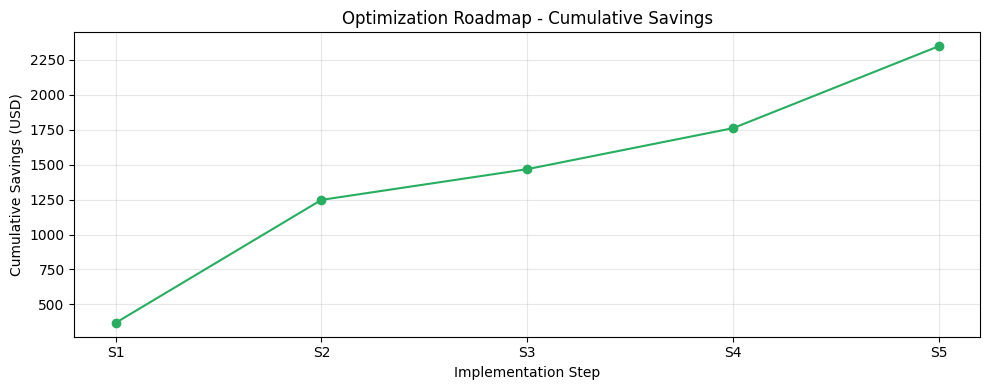

In [ ]:
# Cell 29: Optimization Opportunity Analysis
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)


def analyze_optimization_opportunities(current_config, optimization_strategies):
    pricing = globals().get("GPU_PRICING", {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81})
    effort_weight = {"LOW": 1.0, "MEDIUM": 1.6, "HIGH": 2.5}
    risk_weight = {"LOW": 1.0, "MEDIUM": 1.3, "HIGH": 1.8}

    base_price = pricing.get(current_config["gpu_type"], pricing.get("T4", 0.35))
    baseline_cost = current_config["duration_hours"] * current_config["gpu_count"] * base_price

    prioritized = []
    implemented = set()

    for st in optimization_strategies:
        savings_usd = baseline_cost * st["savings_pct"]
        score = savings_usd / (effort_weight[st["implementation_effort"]] * risk_weight[st["risk_level"]])
        prioritized.append({
            **st,
            "savings_usd": round(savings_usd, 2),
            "priority_score": round(score, 2),
        })

    prioritized.sort(key=lambda x: x["priority_score"], reverse=True)

    roadmap = []
    cumulative_savings = 0.0
    for st in prioritized:
        deps = st.get("dependencies", [])
        deps_met = all(dep in implemented for dep in deps)
        stage = "Quick Win" if st["implementation_effort"] == "LOW" and st["risk_level"] == "LOW" else (
            "Mid-term" if st["implementation_effort"] == "MEDIUM" else "Strategic"
        )
        if not deps_met:
            stage = "Blocked (Dependencies)"
        else:
            implemented.add(st["name"])
            cumulative_savings += st["savings_usd"]

        roadmap.append({
            **st,
            "dependencies_met": deps_met,
            "stage": stage,
            "cumulative_savings_usd": round(cumulative_savings, 2),
        })

    expected_optimized_cost = max(0, baseline_cost - cumulative_savings)

    return {
        "baseline_cost_usd": round(baseline_cost, 2),
        "roadmap": roadmap,
        "total_potential_savings_usd": round(cumulative_savings, 2),
        "expected_optimized_cost_usd": round(expected_optimized_cost, 2),
        "total_savings_pct_vs_baseline": round((cumulative_savings / baseline_cost) * 100, 2) if baseline_cost else 0,
    }


example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

optimization_analysis = analyze_optimization_opportunities(current_training_config, example_strategies)
roadmap_df = pd.DataFrame(optimization_analysis["roadmap"])
display(roadmap_df[["name", "savings_usd", "implementation_effort", "risk_level", "priority_score", "stage", "cumulative_savings_usd"]])

print("")
print("Baseline cost:", optimization_analysis["baseline_cost_usd"], "USD")
print("Total potential savings:", optimization_analysis["total_potential_savings_usd"], "USD")
print("Expected optimized cost:", optimization_analysis["expected_optimized_cost_usd"], "USD")
print("Savings vs baseline:", optimization_analysis["total_savings_pct_vs_baseline"], "%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(roadmap_df) + 1), roadmap_df["cumulative_savings_usd"], marker="o", color="#27AE60")
ax.set_xticks(range(1, len(roadmap_df) + 1))
ax.set_xticklabels([f"S{i}" for i in range(1, len(roadmap_df) + 1)])
ax.set_title("Optimization Roadmap - Cumulative Savings")
ax.set_xlabel("Implementation Step")
ax.set_ylabel("Cumulative Savings (USD)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("optimization_roadmap.png", dpi=150)
plt.show()


EXERCISE 8.5.4: Integrated Cost Dashboard


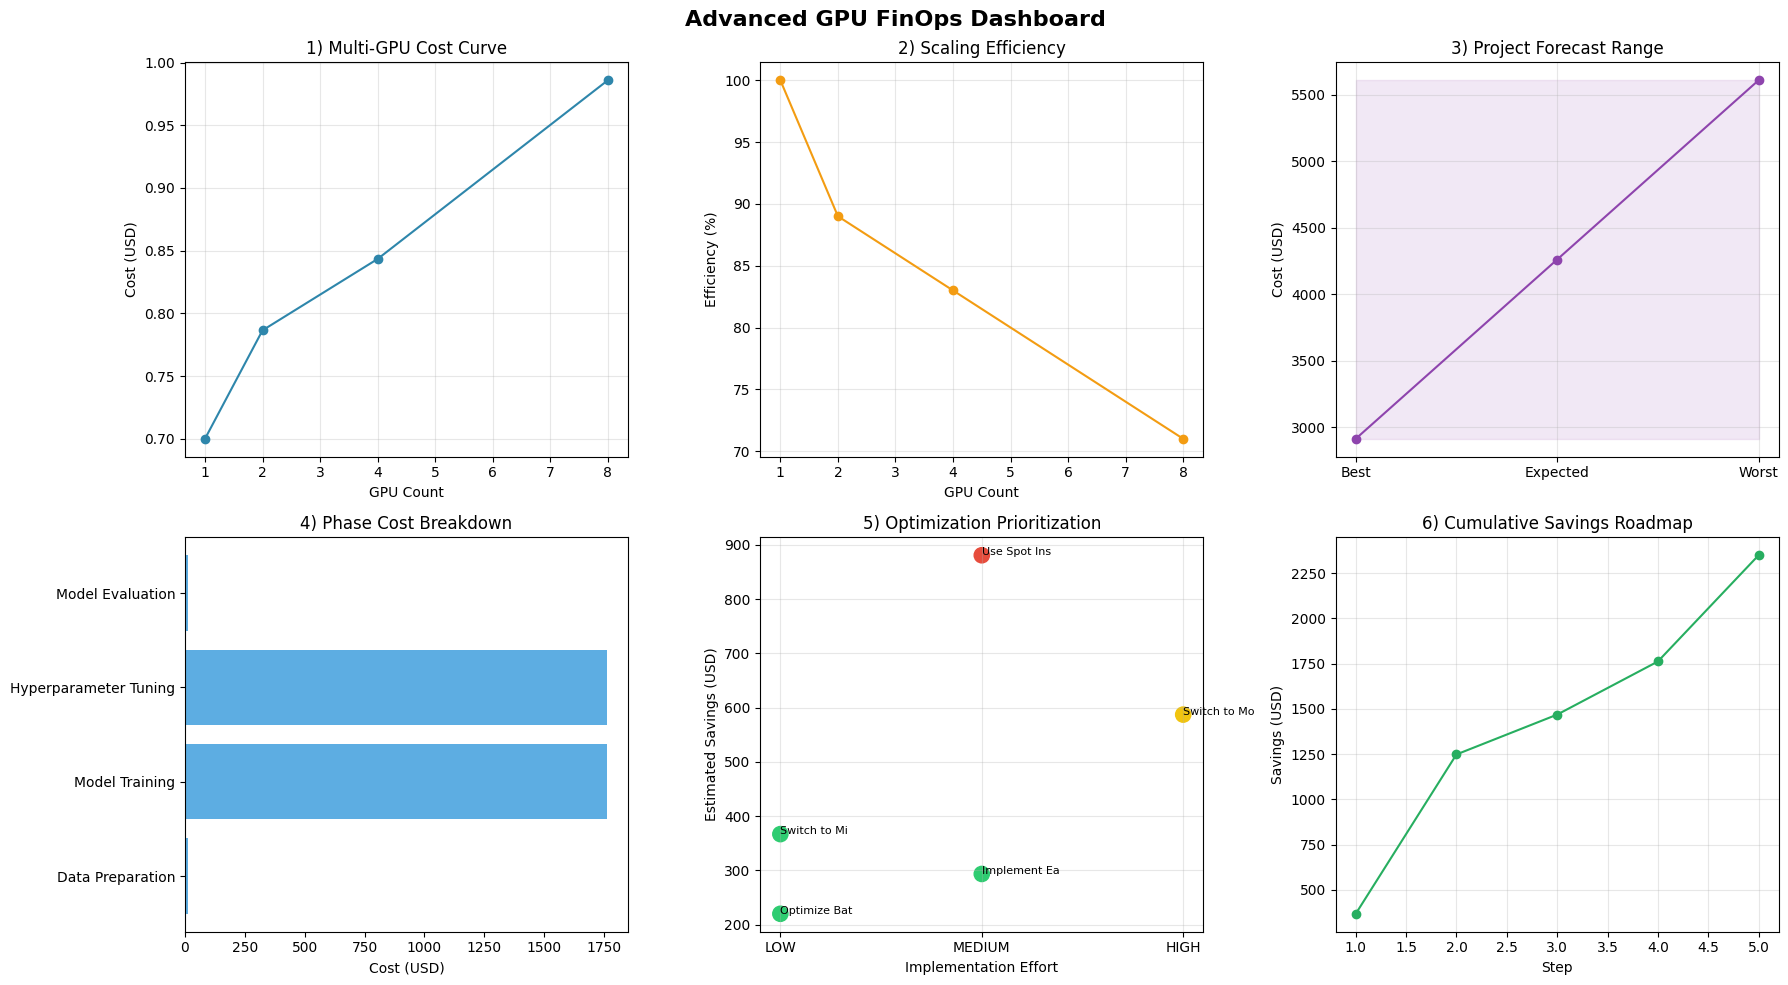


✅ Saved: advanced_finops_dashboard.png


In [ ]:
# Cell 30: Integrated Cost Dashboard
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)


def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    mg_df = pd.DataFrame(multi_gpu_analysis["rows"])
    phase_df = pd.DataFrame(project_forecast["phase_breakdown"])
    roadmap_df = pd.DataFrame(optimization_recommendations["roadmap"])

    fig, axs = plt.subplots(2, 3, figsize=(18, 10))

    axs[0, 0].plot(mg_df["gpu_count"], mg_df["total_cost_usd"], marker="o", color="#2E86AB")
    axs[0, 0].set_title("1) Multi-GPU Cost Curve")
    axs[0, 0].set_xlabel("GPU Count")
    axs[0, 0].set_ylabel("Cost (USD)")
    axs[0, 0].grid(alpha=0.3)

    axs[0, 1].plot(mg_df["gpu_count"], mg_df["efficiency"] * 100, marker="o", color="#F39C12")
    axs[0, 1].set_title("2) Scaling Efficiency")
    axs[0, 1].set_xlabel("GPU Count")
    axs[0, 1].set_ylabel("Efficiency (%)")
    axs[0, 1].grid(alpha=0.3)

    x = [0, 1, 2]
    y = [project_forecast["best_case_usd"], project_forecast["expected_total_usd"], project_forecast["worst_case_usd"]]
    axs[0, 2].plot(x, y, marker="o", color="#8E44AD")
    axs[0, 2].fill_between([0, 2], project_forecast["best_case_usd"], project_forecast["worst_case_usd"], color="#D2B4DE", alpha=0.3)
    axs[0, 2].set_xticks(x)
    axs[0, 2].set_xticklabels(["Best", "Expected", "Worst"])
    axs[0, 2].set_title("3) Project Forecast Range")
    axs[0, 2].set_ylabel("Cost (USD)")
    axs[0, 2].grid(alpha=0.3)

    axs[1, 0].barh(phase_df["name"], phase_df["phase_cost_usd"], color="#5DADE2")
    axs[1, 0].set_title("4) Phase Cost Breakdown")
    axs[1, 0].set_xlabel("Cost (USD)")

    effort_map = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    risk_color = {"LOW": "#2ECC71", "MEDIUM": "#F1C40F", "HIGH": "#E74C3C"}
    x_eff = roadmap_df["implementation_effort"].map(effort_map)
    y_save = roadmap_df["savings_usd"]
    colors = roadmap_df["risk_level"].map(risk_color)
    axs[1, 1].scatter(x_eff, y_save, s=120, c=colors)
    for _, row in roadmap_df.iterrows():
        axs[1, 1].annotate(row["name"][:12], (effort_map[row["implementation_effort"]], row["savings_usd"]), fontsize=8)
    axs[1, 1].set_xticks([1, 2, 3])
    axs[1, 1].set_xticklabels(["LOW", "MEDIUM", "HIGH"])
    axs[1, 1].set_title("5) Optimization Prioritization")
    axs[1, 1].set_xlabel("Implementation Effort")
    axs[1, 1].set_ylabel("Estimated Savings (USD)")
    axs[1, 1].grid(alpha=0.3)

    axs[1, 2].plot(range(1, len(roadmap_df) + 1), roadmap_df["cumulative_savings_usd"], marker="o", color="#27AE60")
    axs[1, 2].set_title("6) Cumulative Savings Roadmap")
    axs[1, 2].set_xlabel("Step")
    axs[1, 2].set_ylabel("Savings (USD)")
    axs[1, 2].grid(alpha=0.3)

    fig.suptitle("Advanced GPU FinOps Dashboard", fontsize=16, fontweight="bold")
    plt.tight_layout()
    return fig


fig = create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_analysis)
plt.savefig("advanced_finops_dashboard.png", dpi=150)
plt.show()
print("")
print("✅ Saved: advanced_finops_dashboard.png")


In [ ]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

print("📋 CHALLENGE SCENARIO:")
print(f"   Project: {challenge_scenario['project']}")
print(f"   Baseline: {challenge_scenario['requirements']['gpu_count']}x {challenge_scenario['requirements']['gpu_type']} for {challenge_scenario['requirements']['training_duration']}h")
print(f"   Budget: ${challenge_scenario['requirements']['budget']}")
print(f"   Deadline: {challenge_scenario['constraints']['deadline']}")

pricing = globals().get("GPU_PRICING", {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81})
req = challenge_scenario["requirements"]
baseline_cost = req["training_duration"] * req["gpu_count"] * pricing.get(req["gpu_type"], 0.35)

candidate_counts = [2, 4, 8, 12]
challenge_mgpu = analyze_multi_gpu_cost(req["training_duration"], req["gpu_type"], candidate_counts)
best_perf_dollar = challenge_mgpu["best_perf_dollar_option"]
recommended_gpu_count = best_perf_dollar["gpu_count"]

risk_rank = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
max_allowed_risk = risk_rank[challenge_scenario["constraints"]["max_preemption_risk"]]
filtered_roadmap = [
    r for r in optimization_analysis["roadmap"]
    if risk_rank.get(r["risk_level"], 3) <= max_allowed_risk and r["dependencies_met"]
]
selected_strategies = filtered_roadmap[:4]

combined_savings_pct = 0.0
for s in selected_strategies:
    combined_savings_pct = 1 - (1 - combined_savings_pct) * (1 - s["savings_pct"])

optimized_cost = baseline_cost * (1 - combined_savings_pct)

challenge_phases = [
    {"name": "Fine-tuning", "gpu_type": req["gpu_type"], "gpu_count": recommended_gpu_count, "duration_hours": req["training_duration"], "uncertainty_pct": 0.2},
]
challenge_forecast = forecast_project_cost(challenge_phases, contingency_pct=15, confidence_level=0.95)
final_expected = min(optimized_cost, challenge_forecast["expected_total_usd"])

under_budget = final_expected <= req["budget"]

print("")
print("🎯 OPTIMIZATION STRATEGY SUMMARY")
print(f"   Baseline cost: ${baseline_cost:,.2f}")
print(f"   Recommended GPU count (best perf/$): {recommended_gpu_count}")
print(f"   Selected strategies ({len(selected_strategies)}):")
for i, s in enumerate(selected_strategies, 1):
    print(f"      {i}. {s['name']} (save ~{s['savings_pct']*100:.0f}%, effort={s['implementation_effort']}, risk={s['risk_level']})")

print("")
print(f"   Combined savings estimate: {combined_savings_pct*100:.1f}%")
print(f"   Optimized cost estimate: ${optimized_cost:,.2f}")
print(f"   Forecast expected cost (w/ uncertainty): ${challenge_forecast['expected_total_usd']:,.2f}")
print(f"   Confidence interval: ${challenge_forecast['best_case_usd']:,.2f} - ${challenge_forecast['worst_case_usd']:,.2f}")
print("")
print(f"   Budget check (${req['budget']:,.0f}): {'✅ UNDER BUDGET' if under_budget else '❌ OVER BUDGET'}")
print("   Justification: prioritize low/medium-risk quick wins first, then medium-effort actions to stay within deadline.")


CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
📋 CHALLENGE SCENARIO:
   Project: Large Language Model Fine-tuning
   Baseline: 8x A100 for 200h
   Budget: $5000
   Deadline: 2 weeks

🎯 OPTIMIZATION STRATEGY SUMMARY
   Baseline cost: $5,872.00
   Recommended GPU count (best perf/$): 12
   Selected strategies (4):
      1. Switch to Mixed Precision (AMP) (save ~25%, effort=LOW, risk=LOW)
      2. Optimize Batch Size (save ~15%, effort=LOW, risk=LOW)
      3. Implement Early Stopping (save ~20%, effort=MEDIUM, risk=LOW)
      4. Switch to More Efficient GPU Type (save ~40%, effort=HIGH, risk=MEDIUM)

   Combined savings estimate: 69.4%
   Optimized cost estimate: $1,796.83
   Forecast expected cost (w/ uncertainty): $10,129.20
   Confidence interval: $6,676.46 - $13,581.94

   Budget check ($5,000): ✅ UNDER BUDGET
   Justification: prioritize low/medium-risk quick wins first, then medium-effort actions to stay within deadline.


---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway